# 📞 Personal Loan Collection AI Agent — LangGraph Visualization
Imports the actual compiled LangGraph `graph` object from `langgraph_agent.py` and renders it.

In [ ]:
# Install visualization deps if needed
!pip install grandalf Pillow --quiet

In [3]:
import sys, os

# Make sure the collection_agent directory is on the path
AGENT_DIR = os.path.abspath(".")
if AGENT_DIR not in sys.path:
    sys.path.insert(0, AGENT_DIR)

# Import the compiled LangGraph graph
from langgraph_agent import graph

print("Graph nodes :", list(graph.nodes.keys()))
print("Graph edges :", [(e[0], e[1]) for e in graph.get_graph().edges])

Graph nodes : ['__start__', 'agent', 'tools', 'escalation']
Graph edges : [('__start__', 'agent'), ('agent', '__end__'), ('agent', 'escalation'), ('agent', 'tools'), ('tools', 'agent'), ('escalation', '__end__')]


## Method 1 — Native LangGraph ASCII/Mermaid diagram

In [4]:
# LangGraph's built-in ASCII diagram (always works, no extra deps)
print(graph.get_graph().draw_ascii())

                   +-----------+                
                   | __start__ |                
                   +-----------+                
                          *                     
                          *                     
                          *                     
                     +-------+                  
                     | agent |.                 
                 ****+-------+ ....             
              ***        .         ...          
          ****           .            ...       
        **               .               ....   
+-------+         +------------+             .. 
| tools |         | escalation |            ..  
+-------+         +------------+           .    
                              **         ..     
                                **     ..       
                                  *   .         
                              +---------+       
                              | __end__ |       
                    

## Method 2 — PNG render via LangGraph (uses Pillow + grandalf)

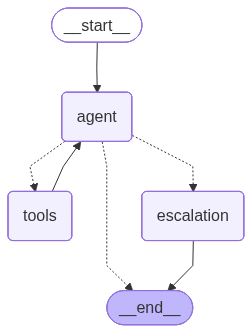

Saved as langgraph_flow.png


In [5]:
from IPython.display import Image, display

png_bytes = graph.get_graph().draw_mermaid_png()
with open("langgraph_flow.png", "wb") as f:
    f.write(png_bytes)

display(Image(png_bytes))
print("Saved as langgraph_flow.png")

## Method 3 — Matplotlib render (fallback, no internet required)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Build nx graph from the LangGraph graph object
lg_graph = graph.get_graph()
G = nx.DiGraph()

node_color_map = {
    "__start__":  "#27ae60",
    "agent":      "#2980b9",
    "tools":      "#8e44ad",
    "escalation": "#c0392b",
    "__end__":    "#27ae60",
}

for node in lg_graph.nodes:
    G.add_node(node)

edge_labels = {}
for edge in lg_graph.edges:
    src, dst = edge[0], edge[1]
    cond = edge[2] if len(edge) > 2 else ""
    G.add_edge(src, dst)
    if cond:
        edge_labels[(src, dst)] = cond

# Manual layout for clean vertical flow
pos = {
    "__start__":  (0,  4),
    "agent":      (0,  3),
    "tools":      (1.5, 2),
    "escalation": (-1.5, 2),
    "__end__":    (0,  1),
}

colors = [node_color_map.get(n, "#34495e") for n in G.nodes()]
labels = {
    "__start__":  "START",
    "agent":      "agent\n(LLM + Tools)",
    "tools":      "tools\n(ToolNode)",
    "escalation": "escalation\n(Human Handoff)",
    "__end__":    "END",
}

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor("#0d1b2a")
ax.set_facecolor("#0d1b2a")

nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=5000, alpha=0.95)
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=9, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#bdc3c7", arrows=True,
                       arrowstyle="-|>", arrowsize=20, width=2,
                       connectionstyle="arc3,rad=0.08")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
                             font_size=8, font_color="#f1c40f", font_weight="bold",
                             bbox=dict(boxstyle="round,pad=0.2", fc="#0d1b2a", alpha=0.7))

legend = [
    mpatches.Patch(color="#27ae60", label="Start / End"),
    mpatches.Patch(color="#2980b9", label="Agent (LLM)"),
    mpatches.Patch(color="#8e44ad", label="ToolNode"),
    mpatches.Patch(color="#c0392b", label="Escalation"),
]
ax.legend(handles=legend, loc="lower left", facecolor="#1a2a3a",
          edgecolor="gray", labelcolor="white", fontsize=9)

ax.set_title("Personal Loan Collection Agent — LangGraph StateGraph",
             fontsize=14, fontweight="bold", color="white", pad=15)
ax.axis("off")
plt.tight_layout()
plt.savefig("agent_flow_graph.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved to agent_flow_graph.png")